# 03 — VAE Advanced Topics

## 📚 Learning Objectives

By completing this notebook, you will:
- Build and train a **Conditional VAE (CVAE)** and generate digits *by class*
- Implement `interpolate_latent()` and use it to morph between digits **across classes**
- Run a **β-VAE experiment**: train β = 1 vs β = 4 and measure the reconstruction ↔ regularization trade-off

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 3, lessons 01-02 (the plain VAE) and Unit 1, lesson 06, whose conditional GAN uses the same label-concatenation trick.

**Used later in:** Course 10 — Unit 3, lesson 04, where a different way of controlling generation — diffusion — takes over.

---

## Real-World Context

Controllable generation is what industry needs: a design tool must produce "a shirt in style X", not "some shirt". Conditioning and disentangled latents (β-VAE) are the two standard levers for that control.


## Part 1 — Conditional VAE

Same trick as the conditional GAN (unit 1, example 06): concatenate a one-hot class label to the **encoder input** and to the **decoder input**. The decoder then learns p(x | z, label) — so at generation time we choose the class and the latent handles the style.


Epoch 5/25 — loss/image: 135.3


Epoch 10/25 — loss/image: 126.9


Epoch 15/25 — loss/image: 123.6


Epoch 20/25 — loss/image: 121.4


Epoch 25/25 — loss/image: 120.1


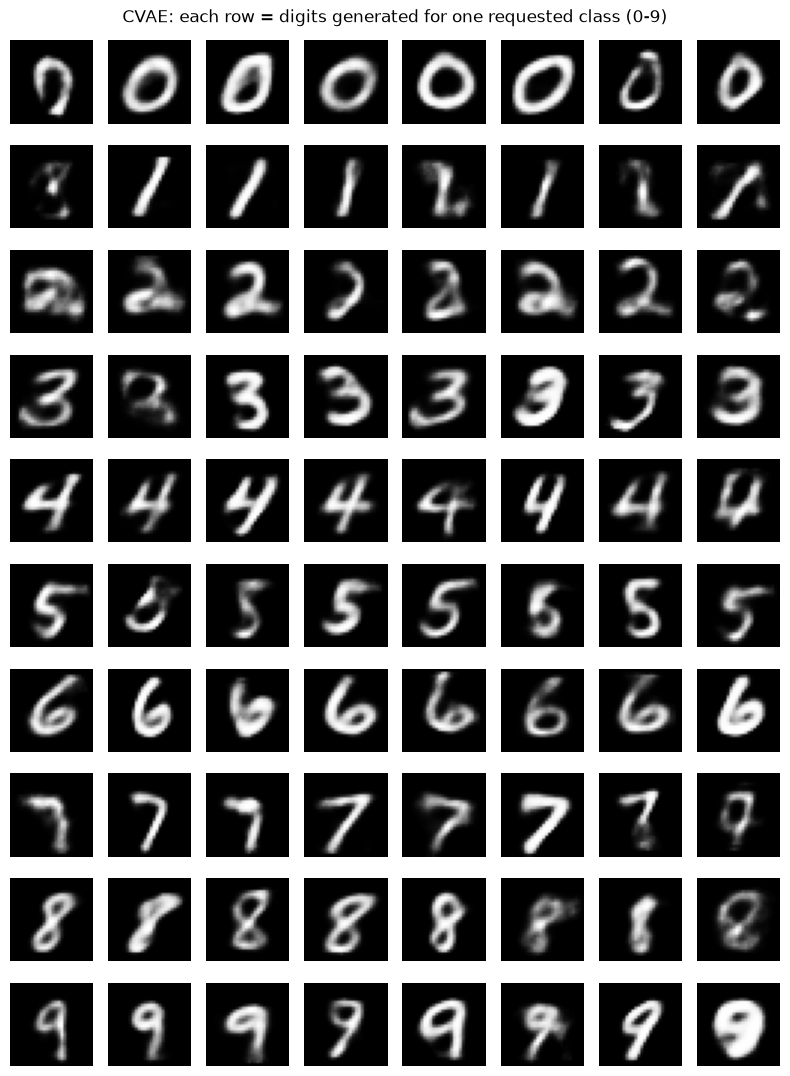

The latent z carries style (slant, thickness); the label carries WHICH digit.



Class-control check: 479/500 generated digits (96%) are
classified as the class we requested — the label input is in charge.


In [1]:
# WHAT/WHY: build a working Conditional VAE — label goes into both encoder
# and decoder — then generate a grid where each ROW is a requested digit
# class, demonstrating label-controlled generation.
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT = 8; N_CLASSES = 10; BATCH = 128   # small z: forces class info into the label

dataset = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=T.ToTensor())
subset  = torch.utils.data.Subset(dataset, range(25_600))
loader  = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

class ConditionalVAE(nn.Module):
    def __init__(self, z=LATENT, n_classes=N_CLASSES):
        super().__init__()
        # Encoder sees image AND label: input 784 + 10
        self.enc    = nn.Sequential(nn.Linear(784 + n_classes, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        # Decoder sees latent AND label: input z + 10
        self.dec    = nn.Sequential(nn.Linear(z + n_classes, 256), nn.ReLU(),
                                    nn.Linear(256, 784), nn.Sigmoid())
    def encode(self, x, y_onehot):
        h = self.enc(torch.cat([x.flatten(1), y_onehot], dim=1))
        return self.mu(h), self.logvar(h)
    def decode(self, z, y_onehot):
        return self.dec(torch.cat([z, y_onehot], dim=1)).view(-1, 1, 28, 28)
    def forward(self, x, y_onehot):
        mu, lv = self.encode(x, y_onehot)
        z = mu + (0.5 * lv).exp() * torch.randn_like(mu)   # reparameterize
        return self.decode(z, y_onehot), mu, lv

cvae = ConditionalVAE()
opt  = optim.Adam(cvae.parameters(), lr=1e-3)

# ── Train: ELBO with the label fed to both halves. KL is weighted ×2 so z
# ── stays close to N(0,I) and cannot smuggle class information — the label
# ── must carry it (Part 3 examines this beta knob systematically).
EPOCHS = 25; KL_WEIGHT = 2.0
for epoch in range(EPOCHS):
    total = 0.0
    for x, y in loader:
        y1h = F.one_hot(y, N_CLASSES).float()
        recon, mu, lv = cvae(x, y1h)
        loss = (F.binary_cross_entropy(recon, x, reduction='sum')
                - KL_WEIGHT * 0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp())) / x.size(0)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — loss/image: {total/len(loader):.1f}")
cvae.eval()

# ── Class-controlled generation: each row = one requested class ───────────
fig, axes = plt.subplots(N_CLASSES, 8, figsize=(8, 11))
with torch.no_grad():
    for cls in range(N_CLASSES):
        z   = torch.randn(8, LATENT)
        y1h = F.one_hot(torch.full((8,), cls), N_CLASSES).float()
        imgs = cvae.decode(z, y1h)
        for j in range(8):
            axes[cls, j].imshow(imgs[j].squeeze(), cmap='gray'); axes[cls, j].axis('off')
plt.suptitle("CVAE: each row = digits generated for one requested class (0-9)")
plt.tight_layout(); plt.show()
print("The latent z carries style (slant, thickness); the label carries WHICH digit.")

# ── VERIFY class control with a classifier, not just by eye ───────────────
# Train a quick digit classifier, then check how often the CVAE's output is
# classified as the class we requested.
torch.manual_seed(0)
clf = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
copt = optim.Adam(clf.parameters(), lr=1e-3); ce = nn.CrossEntropyLoss()
for epoch in range(2):
    for x, y in loader:
        l = ce(clf(x), y); copt.zero_grad(); l.backward(); copt.step()
clf.eval()
with torch.no_grad():
    match = 0
    for cls in range(N_CLASSES):
        z   = torch.randn(50, LATENT)
        y1h = F.one_hot(torch.full((50,), cls), N_CLASSES).float()
        pred = clf(cvae.decode(z, y1h)).argmax(1)
        match += (pred == cls).sum().item()
print(f"\nClass-control check: {match}/500 generated digits ({match/500:.0%}) are")
print("classified as the class we requested — the label input is in charge.")


## Part 2 — Latent Interpolation, Including Across Classes

`interpolate_latent()` below is the general utility: interpolate two latent vectors linearly. With a CVAE we can interpolate the **label vector too** — morphing a 3 into an 8 by sliding both the style code and the (soft) class label.


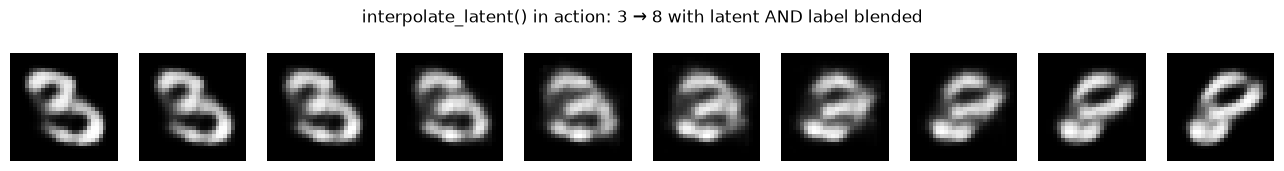

In [2]:
# WHAT/WHY: implement interpolate_latent() and USE it — encode a real 3 and
# a real 8, then decode the interpolation path with a blended soft label,
# producing a class-crossing morph.
def interpolate_latent(z1, z2, n_steps=10):
    """Return n_steps latent vectors linearly interpolated from z1 to z2."""
    alphas = torch.linspace(0, 1, n_steps).view(-1, 1)
    return (1 - alphas) * z1 + alphas * z2      # broadcast over latent dims

test_ds = torchvision.datasets.MNIST('/tmp/mnist', train=False, transform=T.ToTensor())
img_a = next(test_ds[i][0] for i in range(1000) if test_ds[i][1] == 3)
img_b = next(test_ds[i][0] for i in range(1000) if test_ds[i][1] == 8)
y_a = F.one_hot(torch.tensor([3]), N_CLASSES).float()
y_b = F.one_hot(torch.tensor([8]), N_CLASSES).float()

with torch.no_grad():
    z_a, _ = cvae.encode(img_a.unsqueeze(0), y_a)
    z_b, _ = cvae.encode(img_b.unsqueeze(0), y_b)
    zs = interpolate_latent(z_a, z_b, n_steps=10)          # blend the styles
    ys = interpolate_latent(y_a, y_b, n_steps=10)          # blend the labels too
    morphs = cvae.decode(zs, ys)

fig, axes = plt.subplots(1, 10, figsize=(13, 1.7))
for i, ax in enumerate(axes):
    ax.imshow(morphs[i].squeeze(), cmap='gray'); ax.axis('off')
plt.suptitle("interpolate_latent() in action: 3 → 8 with latent AND label blended")
plt.tight_layout(); plt.show()


## Part 3 — β-VAE: Measuring the Trade-off

**β-VAE** (Higgins et al., 2017) multiplies the KL term by β > 1:

loss = reconstruction + **β** · KL

A larger β presses the latent space harder toward N(0, I), which encourages *disentangled* latent dimensions — at the cost of reconstruction quality. That trade-off is measurable, so we measure it: train β = 1 and β = 4 with identical everything else, and print each model's final reconstruction and KL components.


final per-image components   reconstruction     KL
  beta = 1                        104.6         20.5
  beta = 4                        137.8          7.2

Read the table: beta = 4 pushed KL down (a more regular, more disentangled
latent space) and reconstruction up (blurrier outputs) — the trade-off.


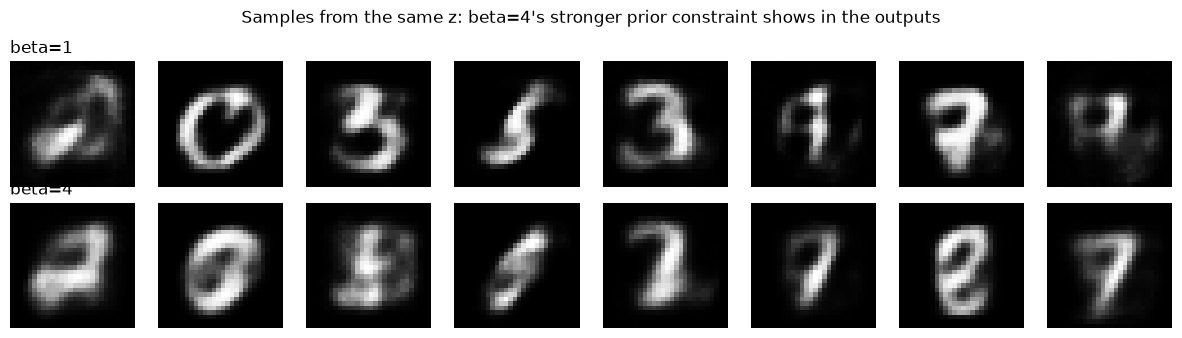

In [3]:
# WHAT/WHY: train two identical VAEs differing only in beta (1 vs 4) and
# print each one's final reconstruction-loss and KL components — making the
# beta-VAE trade-off a measured result instead of a slogan.
# ── Same VAE as before — beta is the only experimental variable ───────────
class VAE(nn.Module):
    def __init__(self, z=16):
        super().__init__()
        self.enc    = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        self.dec    = nn.Sequential(nn.Linear(z, 256), nn.ReLU(),
                                    nn.Linear(256, 784), nn.Sigmoid())
    def forward(self, x):
        h = self.enc(x)
        mu, lv = self.mu(h), self.logvar(h)
        z = mu + (0.5 * lv).exp() * torch.randn_like(mu)
        return self.dec(z).view(-1, 1, 28, 28), mu, lv

def train_beta_vae(beta, epochs=4):
    """Train one VAE with the given beta; return final per-image (recon, kl)."""
    torch.manual_seed(0)                       # identical init for a fair comparison
    model = VAE(); opt = optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        recon_sum = kl_sum = 0.0
        for x, _ in loader:
            recon, mu, lv = model(x)
            recon_loss = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)
            kl_loss    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / x.size(0)
            loss = recon_loss + beta * kl_loss          # <-- the only difference
            opt.zero_grad(); loss.backward(); opt.step()
            recon_sum += recon_loss.item(); kl_sum += kl_loss.item()
    return model, recon_sum / len(loader), kl_sum / len(loader)

# ── Run the experiment: identical models and data, beta = 1 vs beta = 4 ───
vae_b1, recon1, kl1 = train_beta_vae(beta=1)
vae_b4, recon4, kl4 = train_beta_vae(beta=4)

print("final per-image components   reconstruction     KL")
print(f"  beta = 1                      {recon1:7.1f}       {kl1:6.1f}")
print(f"  beta = 4                      {recon4:7.1f}       {kl4:6.1f}")
print("\nRead the table: beta = 4 pushed KL down (a more regular, more disentangled")
print("latent space) and reconstruction up (blurrier outputs) — the trade-off.")

# ── Show samples from both, same latent draws ─────────────────────────────
torch.manual_seed(7)
z = torch.randn(8, 16)
with torch.no_grad():
    s1 = vae_b1.dec(z).view(-1, 28, 28)
    s4 = vae_b4.dec(z).view(-1, 28, 28)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for j in range(8):
    axes[0, j].imshow(s1[j], cmap='gray'); axes[0, j].axis('off')
    axes[1, j].imshow(s4[j], cmap='gray'); axes[1, j].axis('off')
axes[0, 0].set_title("beta=1", loc='left'); axes[1, 0].set_title("beta=4", loc='left')
plt.suptitle("Samples from the same z: beta=4's stronger prior constraint shows in the outputs")
plt.tight_layout(); plt.show()


## 📚 References & Further Reading

**Papers:**
- Sohn et al. (2015) — [Conditional VAE](https://papers.nips.cc/paper/5775-learning-structured-output-representation-using-deep-conditional-generative-models)
- Higgins et al. (2017) — [β-VAE: Learning Basic Visual Concepts](https://openreview.net/forum?id=Sy2fchgcx)
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114)
- Vahdat & Kautz (2020) — [NVAE: A Deep Hierarchical Variational Autoencoder](https://arxiv.org/abs/2007.03898) *(the hierarchical VAE mentioned below)*

**Beyond this notebook:** hierarchical VAEs (NVAE), VQ-VAE (the discrete-latent VAE inside DALL-E 1)


## 📝 Summary

In **03 — VAE Advanced Topics** you built the two standard control mechanisms and measured one trade-off:
- A **Conditional VAE** whose generation you steer by class — verified two ways: the 10-row figure, and a classifier check reporting how often samples match the requested class (printed percentage)
- **`interpolate_latent()`**, implemented and used for a class-crossing 3 → 8 morph
- A **β-VAE experiment** with printed evidence: β = 4 lowered the KL component and raised reconstruction loss relative to β = 1 — regularity bought at the price of fidelity

Next: example 04 leaves the VAE family for **diffusion models** — the architecture behind Stable Diffusion.
